In [ ]:
# !pip --version

pip 26.2.1 from E:\hanwh2609\rag_one\.venv\Lib\site-packages\pip (python 3.12)



### 멀티모달 Mutimodal
- 텍스트, 이미지, 오디오, 비디오

In [8]:
from langchain_teddynote.models import MultiModal
from langchain_teddynote.messages import stream_response
from langchain_openai import ChatOpenAI

In [24]:
import base64
from pathlib import Path

from langchain_core.messages import HumanMessage, SystemMessage

# 객체 생성
llm = ChatOpenAI(
    temperature=0.1,  # 창의성 (0.0 ~ 2.0)
    model_name="gpt-4o-mini",  # 모델명
)


def image_url(image_source):
    """Convert a local image path to a data URL; keep HTTP URLs unchanged."""
    if str(image_source).startswith(("http://", "https://")):
        return str(image_source)

    image_path = Path(image_source)
    mime_type = "image/png" if image_path.suffix.lower() == ".png" else "image/jpeg"
    encoded_image = base64.b64encode(image_path.read_bytes()).decode("utf-8")
    return f"data:{mime_type};base64,{encoded_image}"


def stream_image_response(image_source, user_prompt, system_prompt=None):
    content = [
        {"type": "text", "text": user_prompt},
        {"type": "image_url", "image_url": {"url": image_url(image_source)}},
    ]
    messages = [HumanMessage(content=content)]
    if system_prompt:
        messages.insert(0, SystemMessage(content=system_prompt))

    for token in llm.stream(messages):
        print(token.content, end="", flush=True)
    print()

In [ ]:
# llm = ChatOpenAI(
#     temperature=0.1,
#     model="gpt-4o-mini"
# )

In [26]:
# 멀티모달 객체 생성
multimodal_llm = MultiModal(llm)


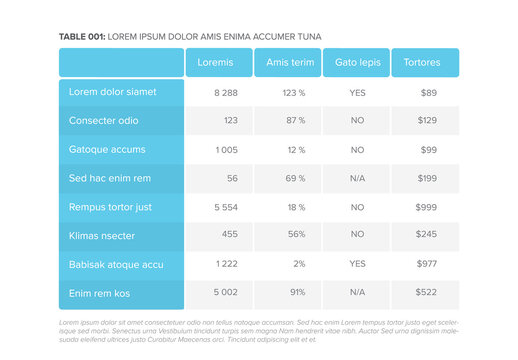

The image presents a table labeled "TABLE 001: LOREM IPSUM DOLOR AMIS ENIMA ACCUMMER TUNA." This table appears to be a mock-up, likely using placeholder text (Lorem Ipsum) commonly used in design and typesetting.

### Table Structure:
1. **Columns**:
   - **Loremis**: This column contains numerical values, possibly representing quantities or scores.
   - **Amis terim**: This column also contains numerical values, likely percentages or related metrics.
   - **Gato lepis**: This column has "YES" or "NO" entries, indicating a binary condition or status.
   - **Tortores**: This column lists monetary values, possibly prices or costs associated with the entries.

2. **Rows**:
   - Each row corresponds to a different item or entry, with various attributes represented in the columns.

### Data Analysis:
- **Numerical Values**: The first column shows values ranging from 123 to 8,288, suggesting a wide range of data points.
- **Percentages**: The second column features percentages, with values l

In [27]:
# page99
IMAGE_URL = "https://t3.ftcdn.net/jpg/03/77/33/96/360_F_377339633_Rtv9I77sSmSNcev8bEcnVxTHrXB4nRJ5.jpg"

# 이미지 파일로 부터 질의
answer = multimodal_llm.stream(IMAGE_URL)
stream_response(answer)

In [28]:
# 샘플 이미지 주소(웹사이트로 부터 바로 인식)
IMAGE_URL = "https://t3.ftcdn.net/jpg/03/77/33/96/360_F_377339633_Rtv9I77sSmSNcev8bEcnVxTHrXB4nRJ5.jpg"

# 이미지 파일로 부터 질의
stream_image_response(
    IMAGE_URL,
    "이미지를 설명해 주세요.",
)

이 이미지는 표 형식으로 구성된 데이터입니다. 표의 제목은 "TABLE 001: LOREM IPSUM DOLOR AMIS ENIMA ACCUMMER TUNA"입니다. 

표는 여러 열로 나뉘어 있으며, 각 열은 다음과 같은 제목을 가지고 있습니다:

- **Loremis**
- **Amis terim**
- **Gato lepis**
- **Tortores**

각 행에는 다양한 데이터가 포함되어 있으며, 숫자와 텍스트가 혼합되어 있습니다. 일부 행에는 "YES" 또는 "NO"와 같은 값이 포함되어 있고, 가격 정보도 나타나 있습니다. 표 아래에는 라틴어로 작성된 설명이 포함되어 있습니다. 

전반적으로 이 표는 특정 데이터 세트를 정리하여 보여주는 형식입니다.


In [30]:
# page101. 시스템 프로프트와 사용자 프롬프트 지정하기
system_prompt = """당신은 표(재무제표) 를 해석하는 금융 AI 어시스턴트 입니다.
당신의 임무는 주어진 테이블 형식의 재무제표를 바탕으로 흥미로운 사실을 정리하여 친절하게 답변하는 것입니다."""

user_prompt = """당신에게 주어진 표는 회사의 재무제표 입니다. 흥미로운 사실을 정리하여 답변하세요."""

In [31]:
# 로컬 PC 에 저장되어 있는 이미지의 경로 입력
IMAGE_PATH_FROM_FILE = "https://storage.googleapis.com/static.fastcampus.co.kr/prod/uploads/202212/080345-661/kwon-01.png"

# 이미지 파일로 부터 질의
stream_image_response(
    IMAGE_PATH_FROM_FILE,
    user_prompt,
    system_prompt,
)

주어진 재무제표를 바탕으로 몇 가지 흥미로운 사실을 정리해 보겠습니다.

1. **유동자산 증가**: 2019년의 유동자산은 8,349,633백만 원으로, 2018년의 8,602,837백만 원에서 감소했습니다. 이는 자산 관리에 있어 주의가 필요함을 시사합니다.

2. **현금 및 현금성 자산 감소**: 현금 및 현금성 자산은 2018년 1,690,862백만 원에서 2019년 1,002,263백만 원으로 크게 감소했습니다. 이는 유동성에 영향을 미칠 수 있습니다.

3. **매출채권 증가**: 매출채권은 2018년 4,004,920백만 원에서 2019년 3,981,935백만 원으로 소폭 감소했지만, 여전히 높은 수준을 유지하고 있습니다.

4. **기타 자산의 변화**: 기타 자산은 2018년 2,426,364백만 원에서 2019년 2,670,294백만 원으로 증가했습니다. 이는 자산 포트폴리오의 다양성을 나타낼 수 있습니다.

5. **비유동자산 증가**: 비유동자산은 2018년 15,127,741백만 원에서 2019년 18,677,453백만 원으로 증가했습니다. 이는 장기적인 투자나 자산 확장을 나타낼 수 있습니다.

이러한 변화들은 회사의 재무 건전성 및 운영 전략에 중요한 영향을 미칠 수 있습니다.
